<a href="https://colab.research.google.com/github/kanchandhole/Data-Scientist/blob/main/11th_April_Ensemble_Techniques_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Data Science Masters

## Q1. What is an Ensemble Technique in Machine Learning?

An **ensemble technique** in machine learning is a method that combines multiple individual models (called *base learners* or *weak learners*) to produce a single, stronger predictive model.

Instead of relying on the predictions of one model, ensemble methods aggregate the outputs of many models to make a final prediction. The core intuition is:

> *"The wisdom of the crowd is greater than any individual expert."*

### Key Characteristics:
- **Base learners**: Individual models used as building blocks (e.g., Decision Trees, Logistic Regression).
- **Aggregation**: Combining predictions via voting (classification) or averaging (regression).
- **Diversity**: Models should be diverse — trained on different data subsets or with different parameters.

### Types of Ensemble Methods:
| Type | Description | Example |
|------|-------------|--------|
| Bagging | Parallel training on bootstrap samples | Random Forest |
| Boosting | Sequential training, each corrects previous errors | XGBoost, AdaBoost |
| Stacking | Meta-model learns from base model predictions | StackingClassifier |
| Voting | Majority vote or average of model predictions | VotingClassifier |

---
## Q2. Why are Ensemble Techniques Used in Machine Learning?

Ensemble techniques are used because individual models are often limited in one or more ways:

### 1. Reduce Variance (Overfitting)
A single complex model may overfit the training data. Averaging multiple models smooths out the noise and reduces variance.

### 2. Reduce Bias (Underfitting)
Boosting sequentially builds models that focus on hard-to-predict examples, reducing the bias of weak learners.

### 3. Improve Generalization
Ensemble models tend to generalize better on unseen data compared to single models.

### 4. Handle Complex Patterns
By combining models, ensembles can capture more complex relationships in the data.

### 5. Robustness
They are less sensitive to outliers and noise in the training data.

### Bias-Variance Tradeoff:
$$\text{Total Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Noise}$$

Ensemble methods help minimize both **Bias** and **Variance** simultaneously.

---
## Q3. What is Bagging?

**Bagging** stands for **B**ootstrap **Agg**regat**ing**. It is an ensemble technique where multiple models are trained **in parallel** on different bootstrap samples of the training data.

### How Bagging Works:
1. **Bootstrap Sampling**: Draw `n` random samples *with replacement* from the training dataset to create multiple subsets.
2. **Parallel Training**: Train a separate base model on each bootstrap sample independently.
3. **Aggregation**:
   - **Classification**: Take the majority vote across all models.
   - **Regression**: Take the average of all model predictions.

### Visual Representation:
```
Training Data
      |
      ├── Bootstrap Sample 1 → Model 1 ──┐
      ├── Bootstrap Sample 2 → Model 2 ──┼──► Aggregate → Final Prediction
      └── Bootstrap Sample N → Model N ──┘
```

### Key Properties:
- Reduces **variance** without increasing bias.
- Works best with **high-variance, low-bias** models (e.g., deep Decision Trees).
- Models are trained **independently** (can be parallelized).

### Most Famous Example:
🌲 **Random Forest** — Bagging of Decision Trees with random feature selection at each split.

### Out-of-Bag (OOB) Error:
Each bootstrap sample leaves out ~37% of data (OOB samples), which can be used for validation without a separate test set.

---
## Q4. What is Boosting?

**Boosting** is an ensemble technique where models are trained **sequentially**, and each new model focuses on correcting the **errors made by the previous models**.

### How Boosting Works:
1. Train a weak learner on the original dataset.
2. Identify misclassified or poorly predicted samples.
3. **Increase the weight** of those difficult samples.
4. Train the next model on the re-weighted dataset.
5. Repeat for `N` iterations.
6. Combine all models using a weighted vote/sum.

### Visual Representation:
```
Model 1 → Errors ──► Model 2 → Errors ──► Model 3 → ... → Final Model
  (weights updated)     (weights updated)
```

### Key Properties:
- Reduces **bias** primarily (also reduces variance).
- Models are trained **sequentially** (cannot be parallelized easily).
- Prone to **overfitting** if not regularized.

### Popular Boosting Algorithms:
| Algorithm | Key Idea |
|-----------|----------|
| AdaBoost | Adjusts sample weights based on errors |
| Gradient Boosting | Fits models to residual errors |
| XGBoost | Regularized gradient boosting |
| LightGBM | Leaf-wise tree growth, fast |
| CatBoost | Handles categorical features natively |

### Bagging vs Boosting:
| Feature | Bagging | Boosting |
|---------|---------|----------|
| Training | Parallel | Sequential |
| Focus | Reduce Variance | Reduce Bias |
| Weighting | Equal | Weighted by error |
| Overfitting Risk | Low | Higher |
| Example | Random Forest | XGBoost |

---
## Q5. What are the Benefits of Using Ensemble Techniques?

### 1. 🎯 Improved Accuracy
Ensembles almost always outperform any single base learner, especially on complex tasks.

### 2. 📉 Reduced Overfitting
Averaging over multiple models reduces overfitting (variance) on the training data.

### 3. 💪 Robustness
Less sensitive to noise, outliers, and specific quirks of the training data.

### 4. 🔄 Flexibility
Can combine different types of models (heterogeneous ensembles like stacking).

### 5. 🏆 State-of-the-Art Performance
Ensemble methods (XGBoost, LightGBM, Random Forest) consistently win machine learning competitions (e.g., Kaggle).

### 6. 📊 Better Probability Estimates
Ensemble models often provide better-calibrated probability estimates.

### 7. 🔍 Feature Importance
Methods like Random Forest provide reliable feature importance scores.

### 8. Handles Class Imbalance
Can be combined with resampling strategies to handle imbalanced datasets effectively.

---
## Q6. Are Ensemble Techniques Always Better than Individual Models?

**No — ensemble techniques are NOT always better than individual models.** There are important trade-offs to consider:

### When Ensembles May NOT Be Better:

| Situation | Reason |
|-----------|--------|
| **Small datasets** | Not enough data to create diverse bootstrap samples |
| **Simple problems** | A single logistic regression may suffice |
| **High interpretability needed** | Ensembles are black-boxes; a single Decision Tree is explainable |
| **Real-time inference** | Ensembles are slow to predict; latency-sensitive apps need fast models |
| **Limited compute** | Training 100s of models is expensive |
| **Base models are identical** | No diversity = no benefit from combining |
| **Already high-quality data** | If data is clean and large, a single neural network may outperform |

### The Core Condition for Ensembles to Help:
> Ensemble methods work best when the individual base learners are:
> 1. **Diverse** — they make different types of errors.
> 2. **Better than random** — each learner performs above chance level.

### Conclusion:
Ensemble techniques are a powerful tool, but the right approach depends on the **problem complexity, data size, interpretability requirements, and computational budget**. Always evaluate with cross-validation.

---
## Q7. How is the Confidence Interval Calculated Using Bootstrap?

The **Bootstrap Confidence Interval** is a non-parametric method that estimates the uncertainty of a statistic (e.g., mean, median, correlation) by resampling from the observed data.

### Steps to Calculate Bootstrap Confidence Interval:

**Step 1: Collect the original sample**
- Original sample of size `n`

**Step 2: Generate B bootstrap samples**
- Draw `B` samples of size `n` **with replacement** from the original sample (typically B = 1000–10000)

**Step 3: Compute the statistic for each bootstrap sample**
$$\hat{\theta}^{*b} = \text{statistic}(\text{bootstrap sample } b) \quad \text{for } b = 1, 2, ..., B$$

**Step 4: Build the bootstrap distribution**
- Collect all B estimates: $\{\hat{\theta}^{*1}, \hat{\theta}^{*2}, ..., \hat{\theta}^{*B}\}$

**Step 5: Compute the Confidence Interval**

#### Method 1 — Percentile Method (most common):
$$CI = \left[\hat{\theta}^{*}_{(\alpha/2)}, \; \hat{\theta}^{*}_{(1-\alpha/2)}\right]$$

For a 95% CI ($\alpha = 0.05$):
$$CI_{95\%} = \left[2.5^{\text{th}} \text{ percentile}, \; 97.5^{\text{th}} \text{ percentile}\right]$$

#### Method 2 — Standard Error Method:
$$CI = \hat{\theta} \pm z_{\alpha/2} \cdot SE_{\text{bootstrap}}$$

where $SE_{\text{bootstrap}} = \text{std}(\{\hat{\theta}^{*b}\})$

### Key Advantage:
Bootstrap CI does **not require normality assumptions** about the population — it works for any statistic!

---
## Q8. How Does Bootstrap Work? What are the Steps Involved?

**Bootstrap** is a powerful resampling technique introduced by Bradley Efron (1979). It allows us to estimate the sampling distribution of almost any statistic using only the available data.

### Core Idea:
> Treat the observed sample as a proxy for the population. Simulate drawing new samples by resampling **with replacement** from the original data.

### Steps Involved in Bootstrap:

```
┌─────────────────────────────────────────────────────────┐
│  STEP 1: Obtain original sample (size n)                │
│  e.g., [12, 15, 14, 16, 13, ...] (n=50)                │
└────────────────────┬────────────────────────────────────┘
                     │
                     ▼
┌─────────────────────────────────────────────────────────┐
│  STEP 2: Draw B bootstrap samples with replacement      │
│  Each sample has size n (same as original)              │
│  Some elements appear multiple times, some not at all   │
└────────────────────┬────────────────────────────────────┘
                     │
                     ▼
┌─────────────────────────────────────────────────────────┐
│  STEP 3: Calculate the statistic for each sample        │
│  θ*1, θ*2, ..., θ*B  (e.g., means)                     │
└────────────────────┬────────────────────────────────────┘
                     │
                     ▼
┌─────────────────────────────────────────────────────────┐
│  STEP 4: Build bootstrap distribution                   │
│  Plot histogram of B statistics                         │
└────────────────────┬────────────────────────────────────┘
                     │
                     ▼
┌─────────────────────────────────────────────────────────┐
│  STEP 5: Compute CI, SE, or bias from the distribution  │
│  95% CI = [2.5th percentile, 97.5th percentile]         │
└─────────────────────────────────────────────────────────┘
```

### Important Properties:
- Each bootstrap sample has the **same size** as the original sample.
- Sampling is done **with replacement** (an element can appear multiple times).
- On average, each bootstrap sample contains about **63.2%** unique observations from the original sample.
- The remaining **~36.8%** are OOB (Out-of-Bag) samples.

### When to Use Bootstrap:
- When the **population distribution is unknown**.
- When **sample size is small**.
- For complex statistics where analytical formulas are hard to derive (e.g., median, correlation, AUC).

---
## Q9. Bootstrap Confidence Interval — Tree Height Problem

### Problem Statement:
A researcher measures the height of **50 trees**:
- Sample mean: **15 meters**
- Standard deviation: **2 meters**

**Goal**: Estimate the **95% confidence interval** for the population mean height using Bootstrap.

### Approach:
Since we don't have the raw data, we simulate a realistic dataset from $\mathcal{N}(15, 2)$ and apply the bootstrap procedure.

In [1]:
# Import Required Libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Step 1: Simulate the Original Sample
# (since raw data is not given, we generate a
#  sample matching the given mean=15, std=2, n=50)

np.random.seed(42)          # For reproducibility

n           = 50            # Sample size
given_mean  = 15.0          # Given sample mean (meters)
given_std   = 2.0           # Given sample std (meters)

# Generate sample from Normal distribution
sample = np.random.normal(loc=given_mean, scale=given_std, size=n)

# Adjust sample to exactly match given statistics
sample = (sample - sample.mean()) / sample.std() * given_std + given_mean

print(f"Original Sample Size  : {len(sample)}")
print(f"Sample Mean           : {sample.mean():.4f} meters")
print(f"Sample Std Dev        : {sample.std():.4f} meters")
print(f"\nFirst 10 values (meters): {np.round(sample[:10], 2)}")

Original Sample Size  : 50
Sample Mean           : 15.0000 meters
Sample Std Dev        : 2.0000 meters

First 10 values (meters): [16.56 15.19 16.89 18.78 14.98 14.98 18.91 17.15 14.47 16.66]


In [3]:
# Step 2: Perform Bootstrap Resampling
B = 10000   # Number of bootstrap samples

bootstrap_means = np.zeros(B)

for i in range(B):
    # Draw a bootstrap sample WITH REPLACEMENT (same size as original)
    boot_sample = np.random.choice(sample, size=n, replace=True)
    # Compute the statistic (mean) for this bootstrap sample
    bootstrap_means[i] = boot_sample.mean()

print(f"Bootstrap iterations completed: {B}")
print(f"Bootstrap Mean of Means       : {bootstrap_means.mean():.4f} meters")
print(f"Bootstrap Std Error           : {bootstrap_means.std():.4f} meters")

Bootstrap iterations completed: 10000
Bootstrap Mean of Means       : 14.9974 meters
Bootstrap Std Error           : 0.2829 meters


In [4]:
# Step 3: Compute 95% Confidence Interval
#         using the Percentile Method

alpha    = 0.05     # Significance level for 95% CI
ci_lower = np.percentile(bootstrap_means, 100 * alpha / 2)       # 2.5th percentile
ci_upper = np.percentile(bootstrap_means, 100 * (1 - alpha / 2)) # 97.5th percentile

print("━" * 50)
print("     BOOTSTRAP 95% CONFIDENCE INTERVAL")
print("━" * 50)
print(f"  Lower Bound : {ci_lower:.4f} meters")
print(f"  Upper Bound : {ci_upper:.4f} meters")
print(f"  CI Width    : {ci_upper - ci_lower:.4f} meters")
print("━" * 50)
print(f"  Interpretation: We are 95% confident that")
print(f"  the true population mean tree height lies")
print(f"  between {ci_lower:.2f} m and {ci_upper:.2f} m.")
print("━" * 50)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
     BOOTSTRAP 95% CONFIDENCE INTERVAL
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Lower Bound : 14.4426 meters
  Upper Bound : 15.5539 meters
  CI Width    : 1.1113 meters
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Interpretation: We are 95% confident that
  the true population mean tree height lies
  between 14.44 m and 15.55 m.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [5]:
# Step 4: Compare with Classical CI (t-distribution)
se_classical   = given_std / np.sqrt(n)
t_critical     = stats.t.ppf(1 - alpha / 2, df=n - 1)
classical_lower = given_mean - t_critical * se_classical
classical_upper = given_mean + t_critical * se_classical

print("━" * 50)
print("     CLASSICAL t-distribution 95% CI")
print("━" * 50)
print(f"  Standard Error : {se_classical:.4f} meters")
print(f"  t-critical     : {t_critical:.4f}")
print(f"  Lower Bound    : {classical_lower:.4f} meters")
print(f"  Upper Bound    : {classical_upper:.4f} meters")
print("━" * 50)
print()
print("━" * 50)
print("           COMPARISON SUMMARY")
print("━" * 50)
print(f"  Method       Lower    Upper    Width")
print(f"  Bootstrap  {ci_lower:.3f}   {ci_upper:.3f}   {ci_upper-ci_lower:.3f}")
print(f"  Classical  {classical_lower:.3f}   {classical_upper:.3f}   {classical_upper-classical_lower:.3f}")
print("━" * 50)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
     CLASSICAL t-distribution 95% CI
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Standard Error : 0.2828 meters
  t-critical     : 2.0096
  Lower Bound    : 14.4316 meters
  Upper Bound    : 15.5684 meters
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
           COMPARISON SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Method       Lower    Upper    Width
  Bootstrap  14.443   15.554   1.111
  Classical  14.432   15.568   1.137
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


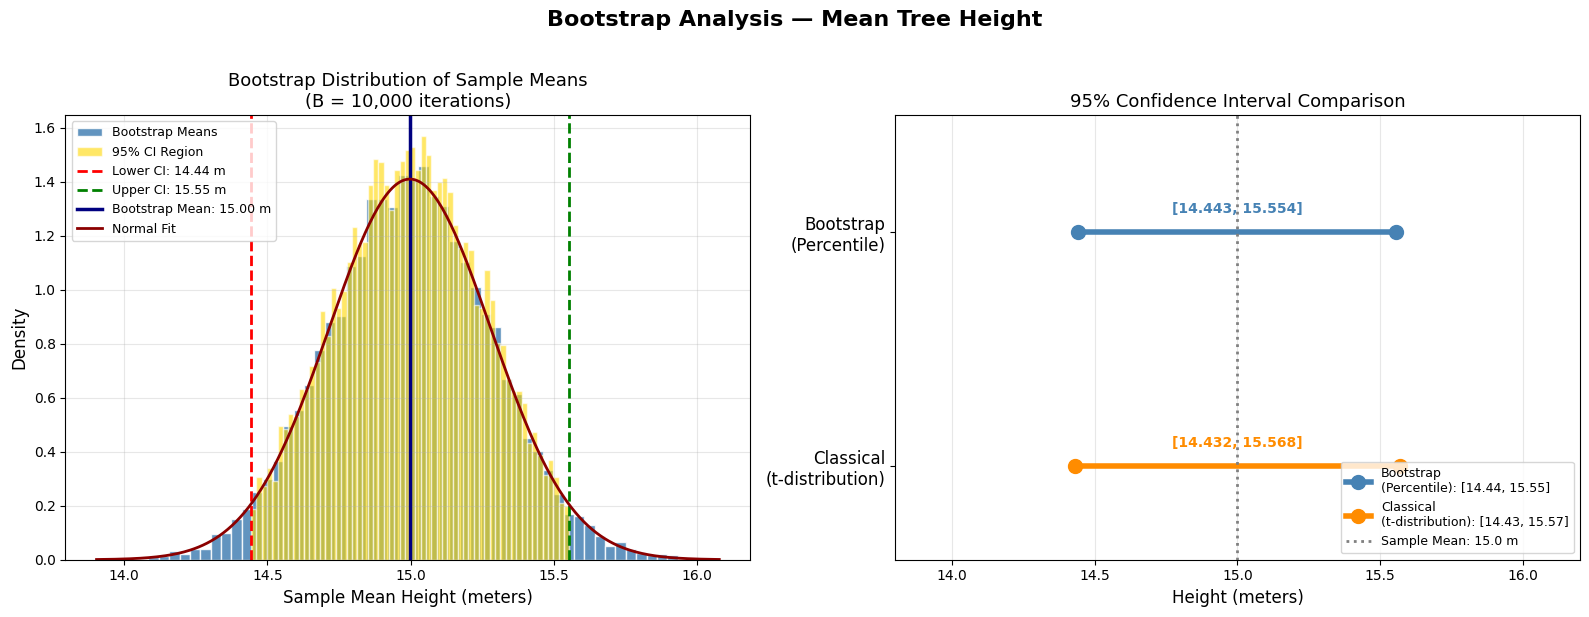


Visualization complete!


In [6]:
# Step 5: Visualization

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Bootstrap Analysis — Mean Tree Height', fontsize=16, fontweight='bold', y=1.02)

# ── Plot 1: Bootstrap Distribution of Sample Means ──
ax1 = axes[0]
ax1.hist(bootstrap_means, bins=60, color='steelblue', edgecolor='white',
         alpha=0.85, density=True, label='Bootstrap Means')

# Shade the CI region
ci_mask = (bootstrap_means >= ci_lower) & (bootstrap_means <= ci_upper)
ax1.hist(bootstrap_means[ci_mask], bins=60, color='gold', edgecolor='white',
         alpha=0.6, density=True, label='95% CI Region')

# Mark CI bounds
ax1.axvline(ci_lower, color='red', linewidth=2, linestyle='--', label=f'Lower CI: {ci_lower:.2f} m')
ax1.axvline(ci_upper, color='green', linewidth=2, linestyle='--', label=f'Upper CI: {ci_upper:.2f} m')
ax1.axvline(bootstrap_means.mean(), color='navy', linewidth=2.5, linestyle='-',
            label=f'Bootstrap Mean: {bootstrap_means.mean():.2f} m')

# Add normal curve overlay
x_vals = np.linspace(bootstrap_means.min(), bootstrap_means.max(), 300)
normal_curve = stats.norm.pdf(x_vals, bootstrap_means.mean(), bootstrap_means.std())
ax1.plot(x_vals, normal_curve, 'darkred', linewidth=2, label='Normal Fit')

ax1.set_xlabel('Sample Mean Height (meters)', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title(f'Bootstrap Distribution of Sample Means\n(B = {B:,} iterations)', fontsize=13)
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(alpha=0.3)

#Plot 2: CI Comparison
ax2 = axes[1]

methods  = ['Bootstrap\n(Percentile)', 'Classical\n(t-distribution)']
lowers   = [ci_lower, classical_lower]
uppers   = [ci_upper, classical_upper]
colors   = ['steelblue', 'darkorange']

y_pos = [1, 0]
for i, (method, lo, hi, col) in enumerate(zip(methods, lowers, uppers, colors)):
    mid = (lo + hi) / 2
    ax2.plot([lo, hi], [y_pos[i], y_pos[i]], 'o-', color=col,
             linewidth=4, markersize=10, label=f'{method}: [{lo:.2f}, {hi:.2f}]')
    ax2.text(mid, y_pos[i] + 0.08, f'[{lo:.3f}, {hi:.3f}]',
             ha='center', fontsize=10, color=col, fontweight='bold')

ax2.axvline(given_mean, color='gray', linestyle=':', linewidth=2, label=f'Sample Mean: {given_mean} m')
ax2.set_yticks(y_pos)
ax2.set_yticklabels(methods, fontsize=12)
ax2.set_xlabel('Height (meters)', fontsize=12)
ax2.set_title('95% Confidence Interval Comparison', fontsize=13)
ax2.legend(fontsize=9, loc='lower right')
ax2.set_xlim(given_mean - 1.2, given_mean + 1.2)
ax2.set_ylim(-0.4, 1.5)
ax2.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('bootstrap_ci_tree_heights.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nVisualization complete!")

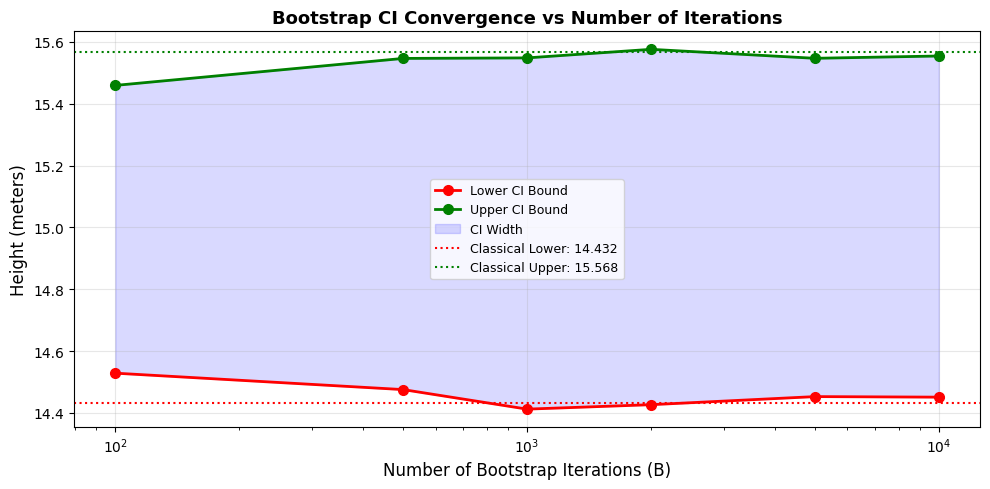

Convergence analysis complete! CI stabilizes as B increases.


In [7]:
# Step 6: Bootstrap Convergence Analysis
# (How CI stabilizes as B increases)

B_values  = [100, 500, 1000, 2000, 5000, 10000]
ci_lowers_track = []
ci_uppers_track = []

for b in B_values:
    boot_means_b = np.array([np.random.choice(sample, size=n, replace=True).mean() for _ in range(b)])
    ci_lowers_track.append(np.percentile(boot_means_b, 2.5))
    ci_uppers_track.append(np.percentile(boot_means_b, 97.5))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(B_values, ci_lowers_track, 'o-', color='red',   linewidth=2, markersize=7, label='Lower CI Bound')
ax.plot(B_values, ci_uppers_track, 'o-', color='green', linewidth=2, markersize=7, label='Upper CI Bound')
ax.fill_between(B_values, ci_lowers_track, ci_uppers_track, alpha=0.15, color='blue', label='CI Width')
ax.axhline(classical_lower, color='red',   linestyle=':', linewidth=1.5, label=f'Classical Lower: {classical_lower:.3f}')
ax.axhline(classical_upper, color='green', linestyle=':', linewidth=1.5, label=f'Classical Upper: {classical_upper:.3f}')

ax.set_xlabel('Number of Bootstrap Iterations (B)', fontsize=12)
ax.set_ylabel('Height (meters)', fontsize=12)
ax.set_title('Bootstrap CI Convergence vs Number of Iterations', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xscale('log')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('bootstrap_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Convergence analysis complete! CI stabilizes as B increases.")